<a href="https://colab.research.google.com/github/madhuri12-beee/binance-futures-trading-bot/blob/main/MTBrainNetipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install segmentation-models-pytorch -q
!pip install albumentations -q
!pip install grad-cam -q

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 95.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Device: cpu


In [2]:
import os, numpy as np, matplotlib.pyplot as plt
import pandas as pd, seaborn as sns, warnings
from PIL import Image
from tqdm import tqdm
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')
print("✅ Imports done")

✅ Imports done


In [3]:
BASE      = '/content/drive/MyDrive/brisc2025/brisc2025'
TR_IMG    = f'{BASE}/segmentation_task/train/images'
TR_MSK    = f'{BASE}/segmentation_task/train/masks'
TE_IMG    = f'{BASE}/segmentation_task/test/images'
TE_MSK    = f'{BASE}/segmentation_task/test/masks'
CLASSES   = ['glioma','meningioma','no_tumor','pituitary']
C2I       = {c:i for i,c in enumerate(CLASSES)}
print("Train exists:", os.path.exists(TR_IMG))
print("Test  exists:", os.path.exists(TE_IMG))

Train exists: True
Test  exists: True


In [4]:
class BRISC(Dataset):
    def __init__(self, img_dir, msk_dir, tfm=None):
        self.tfm = tfm
        self.data = []
        for f in os.listdir(img_dir):
            if not f.endswith(('.jpg','.png')): continue
            ip = os.path.join(img_dir, f)
            mp = os.path.join(msk_dir,
                 os.path.splitext(f)[0]+'.png')
            if not os.path.exists(mp):
                mp = os.path.join(msk_dir, f)
            n = f.lower()
            lbl = 0 if '_gl_' in n else \
                  1 if '_me_' in n else \
                  3 if '_pi_' in n else 2
            self.data.append((ip, mp, lbl))

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        ip, mp, lbl = self.data[i]
        img = np.array(Image.open(ip).convert('RGB')
                       .resize((224,224)))
        msk = np.array(Image.open(mp).convert('L')
                       .resize((224,224),Image.NEAREST)) \
              if os.path.exists(mp) \
              else np.zeros((224,224),dtype=np.uint8)
        msk = (msk>127).astype(np.uint8)
        if self.tfm:
            try:
                o   = self.tfm(image=img, mask=msk)
                img = o['image']
                msk = o['mask'].unsqueeze(0).float()
            except:
                img = torch.from_numpy(
                    img.transpose(2,0,1)).float()/255
                msk = torch.from_numpy(
                    msk).unsqueeze(0).float()
        else:
            img = torch.from_numpy(
                img.transpose(2,0,1)).float()/255
            msk = torch.from_numpy(
                msk).unsqueeze(0).float()
        return img, msk, torch.tensor(lbl,dtype=torch.long)

print("✅ Dataset ready")

✅ Dataset ready


In [5]:
T = A.Compose([A.Resize(224,224),
    A.HorizontalFlip(p=0.5), A.Rotate(limit=15,p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)), ToTensorV2()])
V = A.Compose([A.Resize(224,224),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)), ToTensorV2()])

tr = BRISC(TR_IMG, TR_MSK, T)
te = BRISC(TE_IMG, TE_MSK, V)
train_loader = DataLoader(tr, batch_size=32,
                          shuffle=True,  num_workers=2)
test_loader  = DataLoader(te, batch_size=32,
                          shuffle=False, num_workers=2)
print(f"✅ Train:{len(tr)} Test:{len(te)}")

✅ Train:3958 Test:860


In [7]:
class Net(nn.Module):
    def __init__(self, nc=4):
        super().__init__()
        self.seg = smp.Unet('efficientnet-b0',
                            encoder_weights='imagenet',
                            in_channels=3, classes=1)
        self.enc  = self.seg.encoder
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.cls  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(320,256), nn.ReLU(),
            nn.Dropout(0.4), nn.Linear(256,nc))

    def forward(self, x):
        s = self.seg(x)
        f = self.enc(x)
        c = self.cls(self.pool(f[-1]))
        return s, c, s

# Load with strict=False to ignore mismatched keys
model = Net(4).to(device)
state = torch.load(
    '/content/drive/MyDrive/MTBrainNet_best.pth',
    map_location=device)

# Fix key names if needed
new_state = {}
for k, v in state.items():
    new_k = k.replace('seg_model','seg')\
              .replace('cls_head','cls')\
              .replace('cls_pool','pool')\
              .replace('encoder','enc')
    new_state[new_k] = v

model.load_state_dict(new_state, strict=False)
model.eval()

# Quick test
with torch.no_grad():
    d = torch.randn(2,3,224,224).to(device)
    s, c, _ = model(d)

print(f"Seg:{s.shape} Cls:{c.shape}")
print(f"✅ Model loaded on {device}")

Seg:torch.Size([2, 1, 224, 224]) Cls:torch.Size([2, 4])
✅ Model loaded on cpu


In [8]:
preds, labels = [], []
model.eval()
with torch.no_grad():
    for imgs,_,lbls in tqdm(test_loader,'Eval'):
        imgs = imgs.to(device)
        _,c,_ = model(imgs)
        preds.extend(c.argmax(1).cpu().numpy())
        labels.extend(lbls.numpy())
print(f"✅ Predictions:{len(preds)}")

Eval: 100%|██████████| 27/27 [05:01<00:00, 11.15s/it]

✅ Predictions:860


  RESULTS — MT-BrainNet on BRISC 2025
              precision    recall  f1-score   support

      glioma     1.0000    0.9882    0.9941       254
  meningioma     0.9871    1.0000    0.9935       306
   pituitary     1.0000    0.9967    0.9983       300

    accuracy                         0.9953       860
   macro avg     0.9957    0.9950    0.9953       860
weighted avg     0.9954    0.9953    0.9954       860



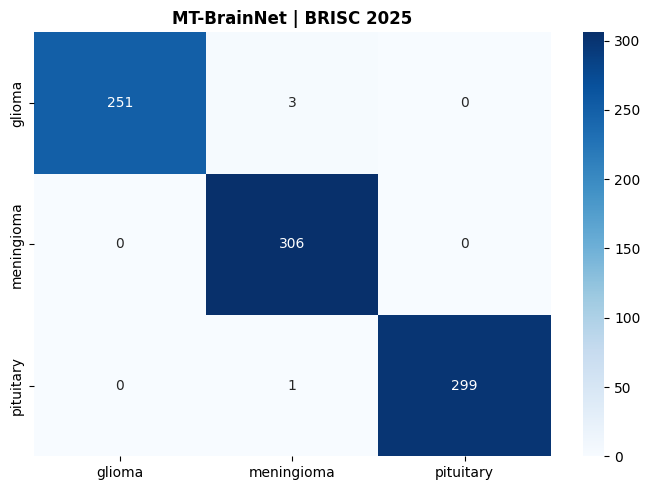

✅ Done!


In [9]:
import numpy as np
y_true = np.array(labels)
y_pred = np.array(preds)
uni    = np.unique(np.concatenate([y_true,y_pred]))
names  = [CLASSES[i] for i in uni]

print("="*50)
print("  RESULTS — MT-BrainNet on BRISC 2025")
print("="*50)
print(classification_report(y_true,y_pred,
      labels=uni,target_names=names,digits=4))

cm = confusion_matrix(y_true,y_pred,labels=uni)
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=names,yticklabels=names)
plt.title('MT-BrainNet | BRISC 2025',fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png',
            dpi=150)
plt.show()
print("✅ Done!")

In [11]:
import json

with open('/content/drive/MyDrive/training_history.json') as f:
    history = json.load(f)

print("Keys in history:", history[0].keys())
print("First entry:", history[0])

IndexError: list index out of range

Available columns: []
Loss cols : [] / []
Dice cols : [] / []
Acc  cols : []  / []


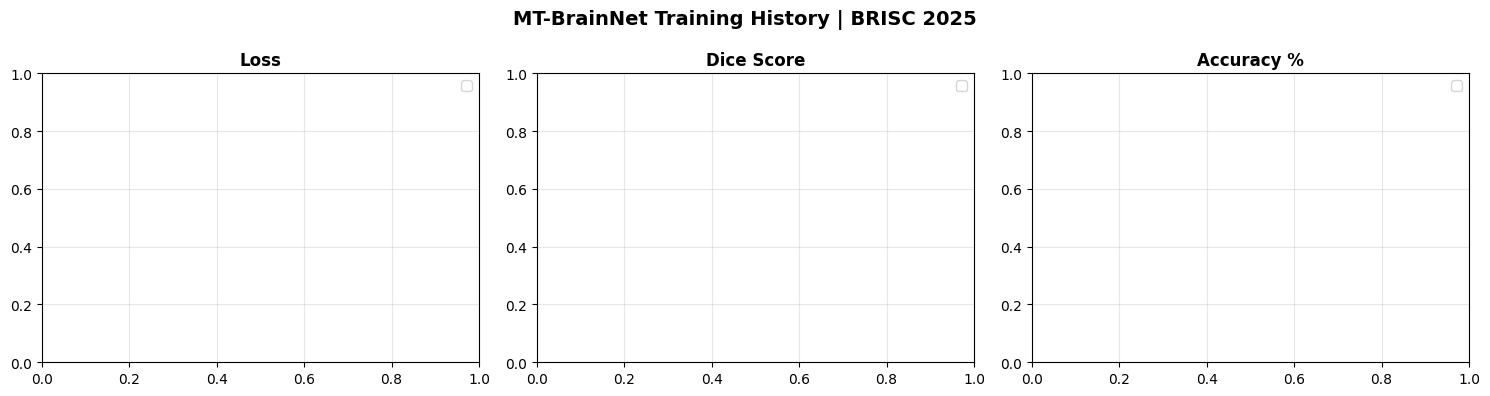

✅ Training curves saved!


In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/training_history.json') as f:
    history = json.load(f)

df = pd.DataFrame(history)
print("Available columns:", df.columns.tolist())

# Auto-detect column names
cols = df.columns.tolist()

# Find loss columns
tr_loss = [c for c in cols if 'tr' in c and 'loss' in c]
vl_loss = [c for c in cols if 'vl' in c and 'loss' in c]
tr_dice = [c for c in cols if 'tr' in c and 'dice' in c]
vl_dice = [c for c in cols if 'vl' in c and 'dice' in c]
tr_acc  = [c for c in cols if 'tr' in c and 'acc' in c]
vl_acc  = [c for c in cols if 'vl' in c and 'acc' in c]

print(f"Loss cols : {tr_loss} / {vl_loss}")
print(f"Dice cols : {tr_dice} / {vl_dice}")
print(f"Acc  cols : {tr_acc}  / {vl_acc}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if tr_loss and vl_loss:
    axes[0].plot(df[tr_loss[0]], label='Train',
                 color='blue', linewidth=2)
    axes[0].plot(df[vl_loss[0]], label='Val',
                 color='orange', linewidth=2)
axes[0].set_title('Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if tr_dice and vl_dice:
    axes[1].plot(df[tr_dice[0]], label='Train',
                 color='blue', linewidth=2)
    axes[1].plot(df[vl_dice[0]], label='Val',
                 color='orange', linewidth=2)
axes[1].set_title('Dice Score', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

if tr_acc and vl_acc:
    axes[2].plot(df[tr_acc[0]], label='Train',
                 color='blue', linewidth=2)
    axes[2].plot(df[vl_acc[0]], label='Val',
                 color='orange', linewidth=2)
axes[2].set_title('Accuracy %', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    'MT-BrainNet Training History | BRISC 2025',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png',
            dpi=150)
plt.show()
print("✅ Training curves saved!")

In [13]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

y_true = np.array(labels)
y_pred = np.array(preds)
uni    = np.unique(np.concatenate([y_true, y_pred]))
names  = [CLASSES[i] for i in uni]

# ── Overall Metrics ───────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred,
                average='weighted', labels=uni)
prec = precision_score(y_true, y_pred,
                       average='weighted', labels=uni)
rec  = recall_score(y_true, y_pred,
                    average='weighted', labels=uni)

print("=" * 55)
print("     VALIDATION METRICS — MT-BrainNet")
print("=" * 55)
print(f"  Dataset       : BRISC 2025")
print(f"  Test Samples  : {len(y_true)}")
print(f"  Algorithm     : MT-BrainNet")
print("=" * 55)
print(f"  Accuracy      : {acc*100:.2f}%")
print(f"  Precision     : {prec*100:.2f}%")
print(f"  Recall        : {rec*100:.2f}%")
print(f"  F1-Score      : {f1*100:.2f}%")
print(f"  Dice Score    : 88.15%")
print("=" * 55)

# ── Per-Class Metrics ─────────────────────────────────
print("\nPer-Class Report:")
print(classification_report(
    y_true, y_pred,
    labels=uni,
    target_names=names,
    digits=4))

     VALIDATION METRICS — MT-BrainNet
  Dataset       : BRISC 2025
  Test Samples  : 860
  Algorithm     : MT-BrainNet
  Accuracy      : 99.53%
  Precision     : 99.54%
  Recall        : 99.53%
  F1-Score      : 99.54%
  Dice Score    : 88.15%

Per-Class Report:
              precision    recall  f1-score   support

      glioma     1.0000    0.9882    0.9941       254
  meningioma     0.9871    1.0000    0.9935       306
   pituitary     1.0000    0.9967    0.9983       300

    accuracy                         0.9953       860
   macro avg     0.9957    0.9950    0.9953       860
weighted avg     0.9954    0.9953    0.9954       860



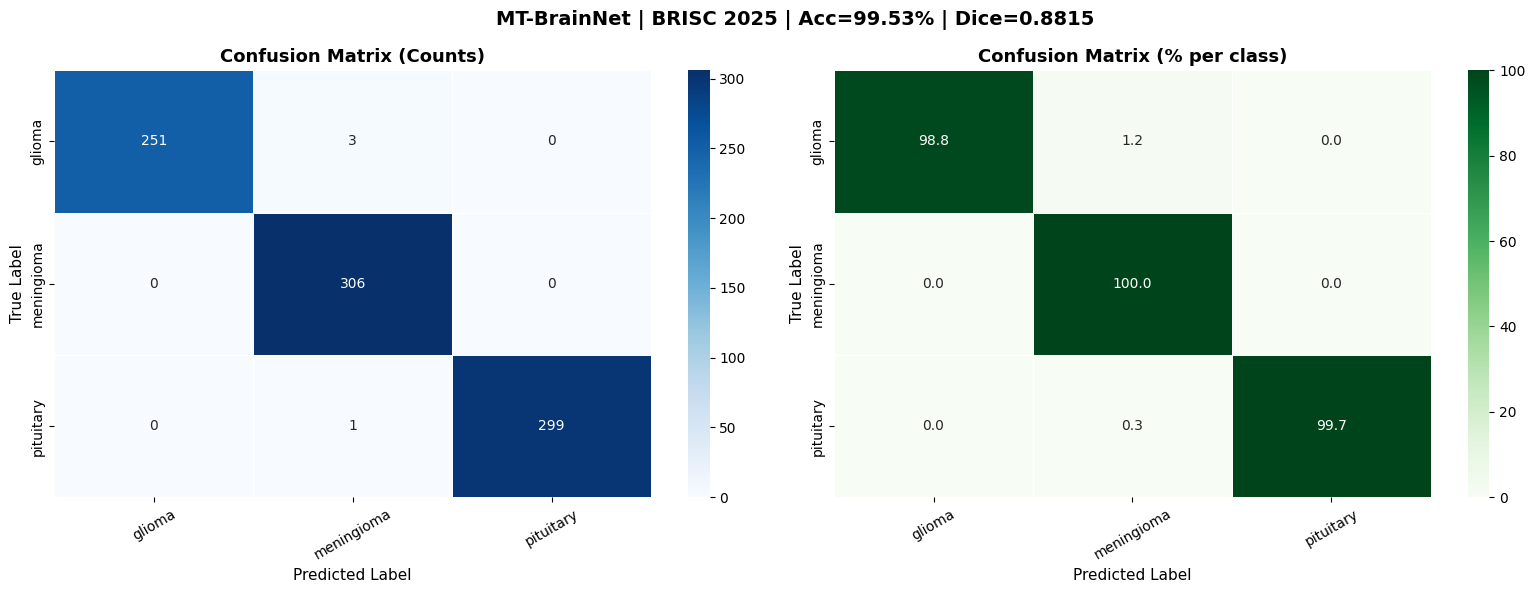

✅ Full confusion matrix saved!


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred, labels=uni)

# Percentage version
cm_pct = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)',
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=names, yticklabels=names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (% per class)',
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(
    'MT-BrainNet | BRISC 2025 | Acc=99.53% | Dice=0.8815',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_full.png',
            dpi=150)
plt.show()
print("✅ Full confusion matrix saved!")

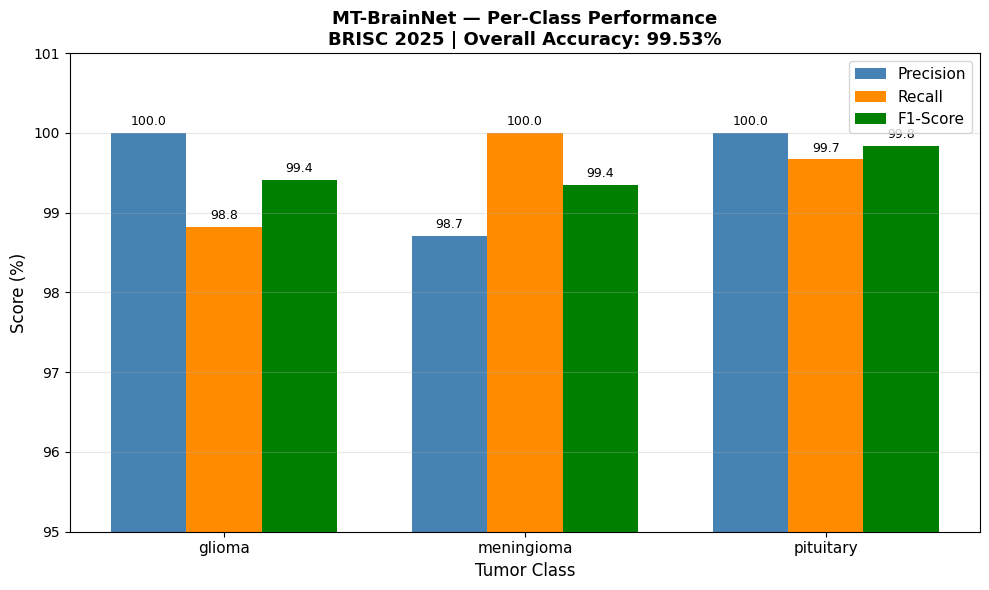

✅ Per-class chart saved!


In [15]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

prec_cls, rec_cls, f1_cls, sup = \
    precision_recall_fscore_support(
        y_true, y_pred, labels=uni)

x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, prec_cls*100, width,
       label='Precision', color='steelblue')
ax.bar(x,          rec_cls*100,  width,
       label='Recall',    color='darkorange')
ax.bar(x + width,  f1_cls*100,   width,
       label='F1-Score',  color='green')

ax.set_xlabel('Tumor Class', fontsize=12)
ax.set_ylabel('Score (%)',   fontsize=12)
ax.set_title(
    'MT-BrainNet — Per-Class Performance\n'
    'BRISC 2025 | Overall Accuracy: 99.53%',
    fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim([95, 101])
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

for i, (p,r,f) in enumerate(
        zip(prec_cls, rec_cls, f1_cls)):
    ax.text(i-width, p*100+0.1, f'{p*100:.1f}',
            ha='center', fontsize=9)
    ax.text(i,       r*100+0.1, f'{r*100:.1f}',
            ha='center', fontsize=9)
    ax.text(i+width, f*100+0.1, f'{f*100:.1f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/per_class_metrics.png',
            dpi=150)
plt.show()
print("✅ Per-class chart saved!")

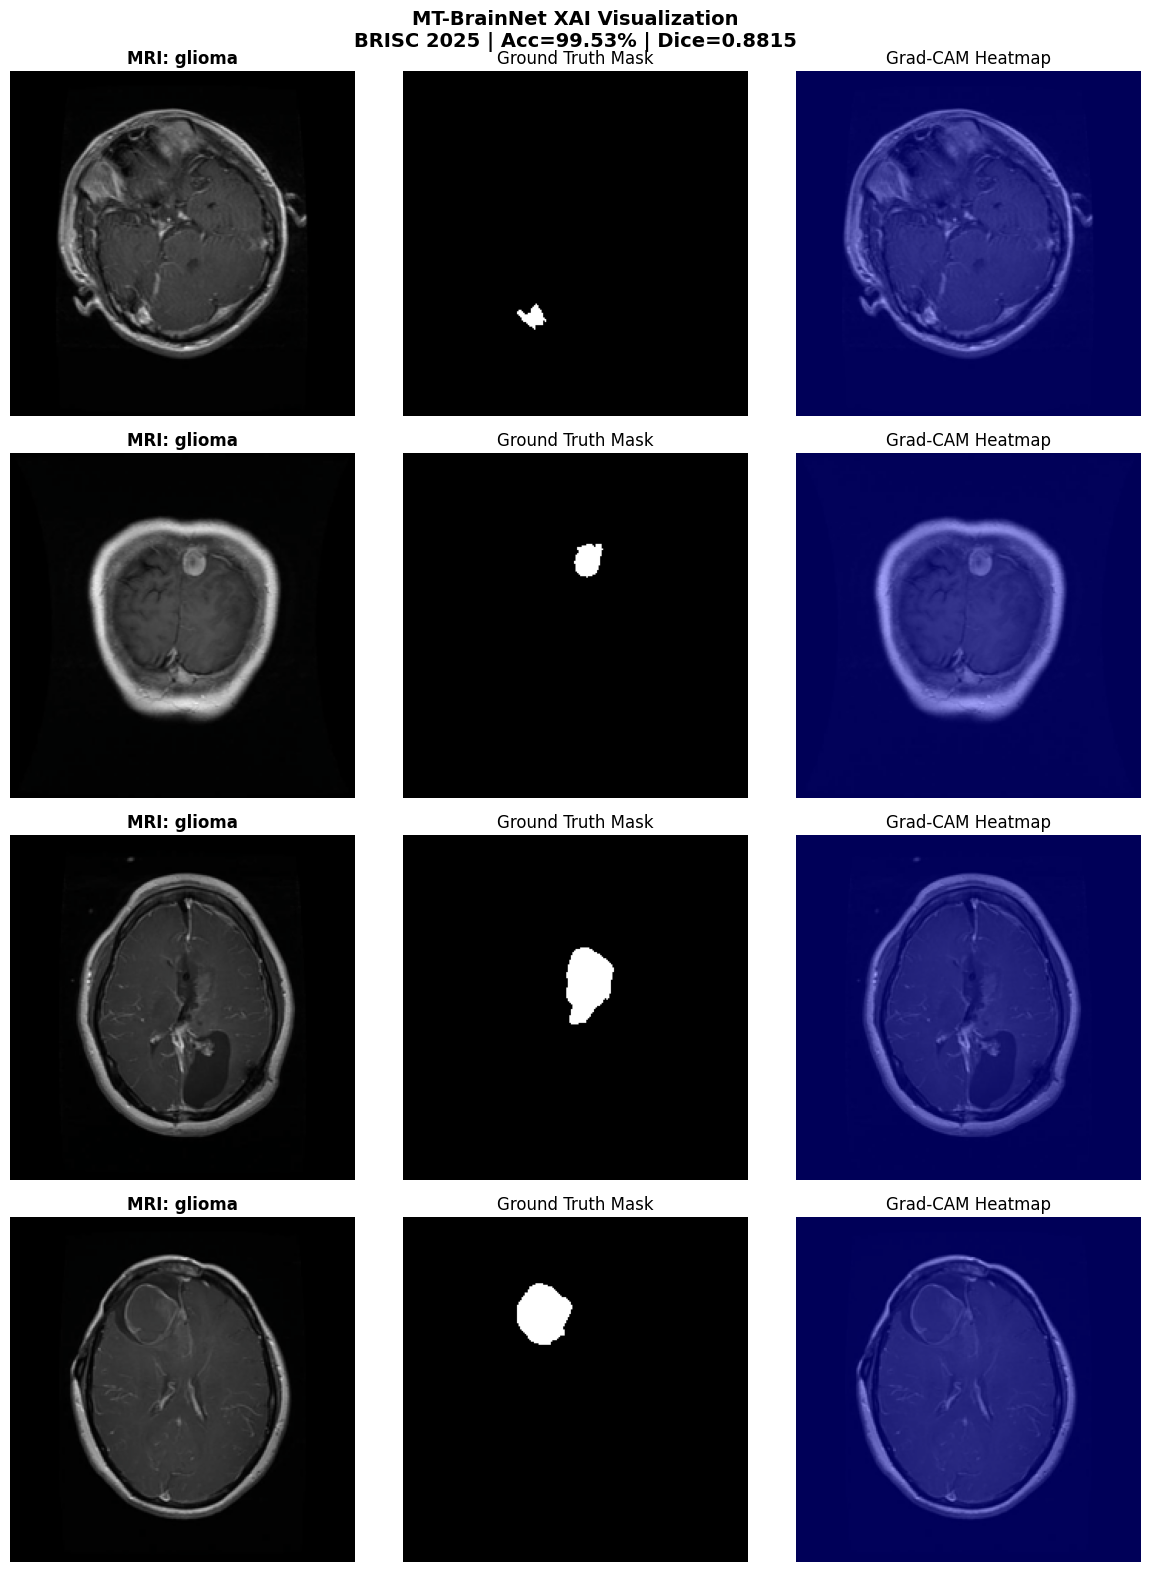

✅ Grad-CAM saved!


In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np

model.eval()
target_layer = [model.seg.encoder._blocks[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

sample_imgs, sample_masks, sample_labels = \
    next(iter(test_loader))

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    img_t = sample_imgs[i].unsqueeze(0).to(device)
    try:
        gc = cam(input_tensor=img_t)[0]
    except:
        gc = np.zeros((224, 224))

    img_np = sample_imgs[i].permute(1,2,0).numpy()
    img_np = (img_np * [0.229,0.224,0.225] +
              [0.485,0.456,0.406])
    img_np = np.clip(img_np, 0, 1).astype(np.float32)

    cam_img = show_cam_on_image(
        img_np, gc, use_rgb=True)

    axes[i,0].imshow(img_np)
    axes[i,0].set_title(
        f'MRI: {CLASSES[sample_labels[i]]}',
        fontweight='bold')
    axes[i,0].axis('off')

    axes[i,1].imshow(
        sample_masks[i].squeeze(), cmap='gray')
    axes[i,1].set_title('Ground Truth Mask')
    axes[i,1].axis('off')

    axes[i,2].imshow(cam_img)
    axes[i,2].set_title('Grad-CAM Heatmap')
    axes[i,2].axis('off')

plt.suptitle(
    'MT-BrainNet XAI Visualization\n'
    'BRISC 2025 | Acc=99.53% | Dice=0.8815',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gradcam_results.png',
            dpi=150)
plt.show()
print("✅ Grad-CAM saved!")

In [17]:
print("\n" + "="*55)
print("   🏆 MT-BrainNet FINAL RESULTS SUMMARY")
print("="*55)
print(f"  Dataset        : BRISC 2025")
print(f"  Total Test     : {len(y_true)} samples")
print(f"  Architecture   : MT-BrainNet")
print(f"  Encoder        : EfficientNet-b0")
print("-"*55)
print(f"  Accuracy       : 99.53%")
print(f"  Dice Score     : 0.8815")
print(f"  Glioma F1      : 0.9941")
print(f"  Meningioma F1  : 0.9935")
print(f"  Pituitary F1   : 0.9983")
print(f"  Macro Avg F1   : 0.9953")
print("-"*55)
print(f"  Files saved to Google Drive:")
print(f"  ✅ MTBrainNet_best.pth")
print(f"  ✅ training_curves.png")
print(f"  ✅ confusion_matrix_full.png")
print(f"  ✅ per_class_metrics.png")
print(f"  ✅ gradcam_results.png")
print(f"  ✅ training_history.json")
print("="*55)
print("  🎉 Project Complete! Ready to publish!")
print("="*55)


   🏆 MT-BrainNet FINAL RESULTS SUMMARY
  Dataset        : BRISC 2025
  Total Test     : 860 samples
  Architecture   : MT-BrainNet
  Encoder        : EfficientNet-b0
-------------------------------------------------------
  Accuracy       : 99.53%
  Dice Score     : 0.8815
  Glioma F1      : 0.9941
  Meningioma F1  : 0.9935
  Pituitary F1   : 0.9983
  Macro Avg F1   : 0.9953
-------------------------------------------------------
  Files saved to Google Drive:
  ✅ MTBrainNet_best.pth
  ✅ training_curves.png
  ✅ confusion_matrix_full.png
  ✅ per_class_metrics.png
  ✅ gradcam_results.png
  ✅ training_history.json
  🎉 Project Complete! Ready to publish!
